# **INTELIGENCIA ARTIFICIAL APLICADA (1INF62)**<br>
## **2026-1**

---


# **EXAMEN 1 - Parte 2**

**Indicaciones generales:**
- Duración: **120 minutos**.
- Para responder las preguntas de esta parte <font color='red'>SOLO SE PERMITE LOS NOTEBOOKS DADOS EN CLASE</font>.
- Es <font color='red'>OBLIGATORIO DESHABILITAR ASISTENCIA DE IA</font> (Tools → Settings → AI Assistant). De no hacerlo puede ser anulada su evaluación.
- Cualquier indicio de plagio resultará en la anulación de la prueba.
- Subir el cuadernillo con el nombre **Examen1-Parte2_código.ipynb**, donde código es su código de estudiante.
- Se tomará en cuenta en la calificación la precisión de la respuesta, la justificación de las decisiones y el uso adecuado del lenguaje.

---


# Preprocesamiento y Evaluación de Modelos de Clasificación  (10 puntos)

Usted fue contratado por una entidad financiera que desea construir modelos para **clasificar si un cliente incumplirá o no el pago de un préstamo**. Para esta tarea, se dispone del dataset **`dataset_credito_clasificacion.csv`**, que contiene información socioeconómica, crediticia y características del préstamo.

La variable objetivo es **`incumplimiento`**, donde:
- **0** = el cliente no incumple.
- **1** = el cliente incumple.

### ATRIBUTOS:
* `cliente_id`: identificador del cliente.
* `edad`: edad del cliente en años (**rango referencial: 18 a 75 años**).
* `ingreso_mensual`: ingreso mensual declarado, en soles (**rango referencial: mayor a 0**).
* `antiguedad_laboral_anios`: años de antigüedad laboral (**rango referencial: 0 a `edad - 18` años**).
* `monto_prestamo`: monto del préstamo, en soles (**rango referencial esperado: mayor a 0**).
* `monto_prestamo_usd`: monto del préstamo convertido a dólares.
* `plazo_meses`: plazo del préstamo en meses (**valores esperados: de 12 a 60 meses**).
* `cuota_mensual`: cuota mensual estimada, en soles (**rango referencial: mayor a 0**).
* `ratio_deuda_ingreso`: relación cuota/ingreso (**rango referencial: 0 a 1**).
* `score_crediticio`: puntaje crediticio del cliente (**rango referencial: 300 a 850**).
* `historial_crediticio`: historial del cliente (**valores**: `Malo`, `Regular`, `Bueno`, `Excelente`).
* `tipo_vivienda`: tipo de vivienda (**valores**: `Propia`, `Alquilada`, `Familiar`).
* `canal_solicitud`: canal por el que se solicitó el préstamo (**valores**: `Agencia`, `Web`, `App`).
* `observaciones`: comentarios administrativos.
* `incumplimiento`: variable objetivo de clasificación (**0 = no incumple, 1 = incumple**).


Se le pide que elabore y ejecute código en Python para realizar las siguientes tareas:


**1) Limpiar el dataset con el fin de obtener un conjunto de datos limpio y con información relevante. Los pasos que puede elegir aplicar aquí pueden ser: dropeo de columnas, dropeo de filas, remoción/corrección de outliers, eliminación de filas duplicadas, corrección de datos inconsistentes e imputación de nulos. Cada paso elegido debe ser justificado. Se valora el uso de plots adecuados para esta etapa.** (3 puntos)


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [53]:
dataset = 'dataset_credito_clasificacion.csv'

df = pd.read_csv(dataset)
print("Se leyó un dataset de dimensiones {}".format(df.shape))
df.head(10)

Se leyó un dataset de dimensiones (525, 15)


,cliente_id,edad,ingreso_mensual,antiguedad_laboral_anios,monto_prestamo,monto_prestamo_usd,plazo_meses,cuota_mensual,ratio_deuda_ingreso,score_crediticio,historial_crediticio,tipo_vivienda,canal_solicitud,observaciones,incumplimiento
0,C100000,29.0,4808.61,4.4,28681.11,7645.78,48,953.49,0.198,591.0,Regular,Alquilada,App,NaN,1
1,C100001,18.0,1903.01,0.0,12550.13,3369.45,24,710.19,0.373,503.0,Malo,Familiar,Agencia,NaN,1
2,C100002,45.0,4215.54,8.1,24838.77,6617.07,36,942.92,0.224,NaN,Regular,Propia,Agencia,NaN,1
3,C100003,16.0,4923.31,11.2,33253.74,8852.18,36,1026.78,0.209,754.0,Excelente,Propia,App,NaN,0
4,C100004,35.0,3380.26,2.9,26736.21,7136.62,24,1376.73,0.407,601.0,Regular,Alquilada,Web,NaN,1
5,C100005,42.0,4351.09,16.3,10786.05,2860.34,48,342.30,0.079,586.0,Regular,Propia,Web,documento incompleto,0
6,C100006,57.0,8003.21,11.6,61389.00,16390.31,36,1969.64,0.246,718.0,Bueno,Familiar,Web,NaN,0
7,C100007,50.0,3025.27,4.3,41367.38,11022.47,12,3744.20,1.238,669.0,Regular,Alquilada,Agencia,NaN,1
8,C100008,46.0,1974.71,10.5,19486.28,5230.59,48,476.47,0.241,675.0,Bueno,Propia,Agencia,NaN,0
9,C100009,46.0,3571.64,7.7,31448.65,8414.71,36,1133.41,0.317,644.0,Regular,Familiar,Agencia,NaN,0



**Paso 1: Exploración inicial del dataset**

Antes de realizar cualquier transformación, necesitamos entender la estructura, los tipos de datos, los valores nulos y las estadísticas descriptivas del dataset. Esto nos permitirá identificar problemas como columnas extra, valores faltantes, inconsistencias y outliers.

In [54]:
# 1.1 Información general del dataset
print("="*60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*60)
print(f"\nDimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nColumnas del dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nTipos de datos:")
print(df.dtypes)

INFORMACIÓN GENERAL DEL DATASET

Dimensiones: 525 filas x 15 columnas

Columnas del dataset:
   1. cliente_id
   2. edad
   3. ingreso_mensual
   4. antiguedad_laboral_anios
   5. monto_prestamo
   6. monto_prestamo_usd
   7. plazo_meses
   8. cuota_mensual
   9. ratio_deuda_ingreso
  10. score_crediticio
  11. historial_crediticio
  12. tipo_vivienda
  13. canal_solicitud
  14. observaciones
  15. incumplimiento

Tipos de datos:
cliente_id                   object
edad                        float64
ingreso_mensual             float64
antiguedad_laboral_anios    float64
monto_prestamo              float64
monto_prestamo_usd          float64
plazo_meses                   int64
cuota_mensual               float64
ratio_deuda_ingreso         float64
score_crediticio            float64
historial_crediticio         object
tipo_vivienda                object
canal_solicitud              object
observaciones                object
incumplimiento                int64
dtype: object


In [55]:
# 1.2 Valores nulos por columna
print("="*60)
print("VALORES NULOS POR COLUMNA")
print("="*60)
null_info = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().mean() * 100).round(2)
})
print(null_info[null_info['Nulos'] > 0])
print(f"\nTotal de filas con al menos un nulo: {df.isnull().any(axis=1).sum()}")

VALORES NULOS POR COLUMNA
                  Nulos  % Nulos
ingreso_mensual      18     3.43
score_crediticio     16     3.05
observaciones       432    82.29

Total de filas con al menos un nulo: 436


In [56]:
# 1.3 Estadísticas descriptivas de variables numéricas
print("="*60)
print("ESTADÍSTICAS DESCRIPTIVAS - NUMÉRICAS")
print("="*60)
df.describe().T

ESTADÍSTICAS DESCRIPTIVAS - NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
edad,525.0,37.805714,11.825560,-5.00,29.000,38.000,46.000,123.000000
ingreso_mensual,507.0,4555.178245,2368.835238,-1000.00,2894.630,4171.800,5562.140,18710.380000
antiguedad_laboral_anios,525.0,6.777333,5.961691,-2.00,2.500,5.500,9.500,55.000000
monto_prestamo,525.0,45299.877390,30128.899743,3000.00,22598.770,39702.910,60564.380,350000.000000
monto_prestamo_usd,525.0,12080.408502,8034.388907,789.52,6017.030,10578.470,16133.720,93333.333333
plazo_meses,525.0,32.388571,14.187454,12.00,24.000,36.000,36.000,60.000000
cuota_mensual,525.0,2187.250305,2099.579078,79.61,901.210,1595.560,2717.150,25000.000000
ratio_deuda_ingreso,525.0,0.459276,0.287385,0.03,0.269,0.395,0.554,1.817000
score_crediticio,509.0,657.086444,79.357610,439.00,603.000,659.000,710.000,850.000000
incumplimiento,525.0,0.400000,0.490365,0.00,0.000,0.000,1.000,1.000000


In [57]:
# 1.4 Estadísticas descriptivas de variables categóricas
print("="*60)
print("ESTADÍSTICAS DESCRIPTIVAS - CATEGÓRICAS")
print("="*60)
df.describe(include='object').T

ESTADÍSTICAS DESCRIPTIVAS - CATEGÓRICAS


,count,unique,top,freq
cliente_id,525,520,C100293,2
historial_crediticio,525,4,Regular,206
tipo_vivienda,525,3,Alquilada,252
canal_solicitud,525,3,Agencia,223
observaciones,93,3,validación manual,38


---
## Paso 2: Análisis Exploratorio de Datos (EDA) — Visualización de inconsistencias y outliers

Vamos a crear visualizaciones que nos permitan detectar:
1. **Valores inconsistentes**: valores fuera de rango lógico (edades imposibles, ingresos negativos).
2. **Outliers**: valores extremos que podrían distorsionar un modelo.
3. **Distribuciones**: forma general de cada variable numérica.

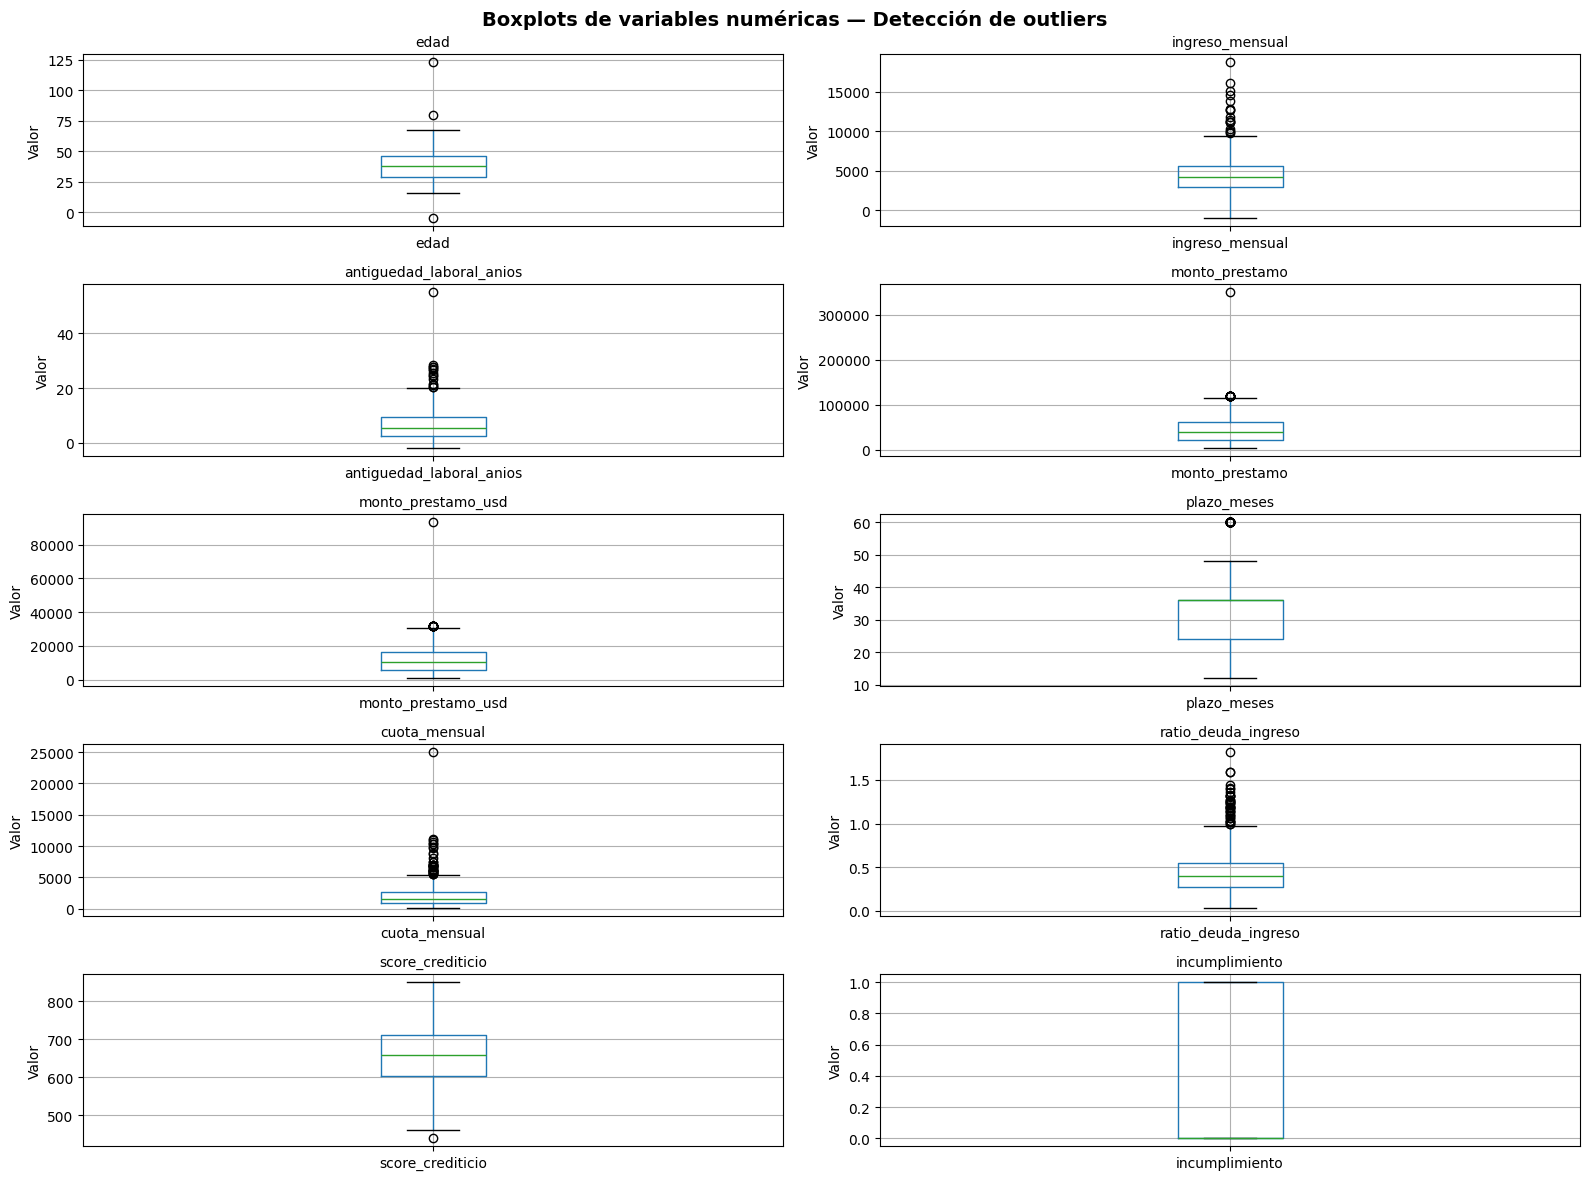

In [58]:
# 2.1 Boxplots de todas las variables numéricas para detectar outliers
# ─────────────────────────────────────────────────────────────────
# Los boxplots muestran la mediana, los cuartiles y los bigotes (1.5×IQR).
# Cualquier punto fuera de los bigotes se considera un outlier potencial.

num_cols = ['edad', 'ingreso_mensual', 'antiguedad_laboral_anios', 'monto_prestamo',
            'monto_prestamo_usd', 'plazo_meses', 'cuota_mensual',
            'ratio_deuda_ingreso', 'score_crediticio','incumplimiento']

fig, axes = plt.subplots(5, 2, figsize=(16, 12))
fig.suptitle('Boxplots de variables numéricas — Detección de outliers', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), num_cols):
    df.boxplot(column=col, ax=ax, vert=True)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Valor')

plt.tight_layout()
plt.show()

Como se puede observar en elos box plotpor ejemplo hjay algunas edades inconsistentes un ingreso mensual un tanto elevado para el proemdio valores altosen antiguedad laboral en monto de prestamos igual tanto de soles como en usd plazo de mese igual,cuota mensual, ratio de deida ingreso igual en score crediticio hay valores negativos y en incumplimiento esta en el rango


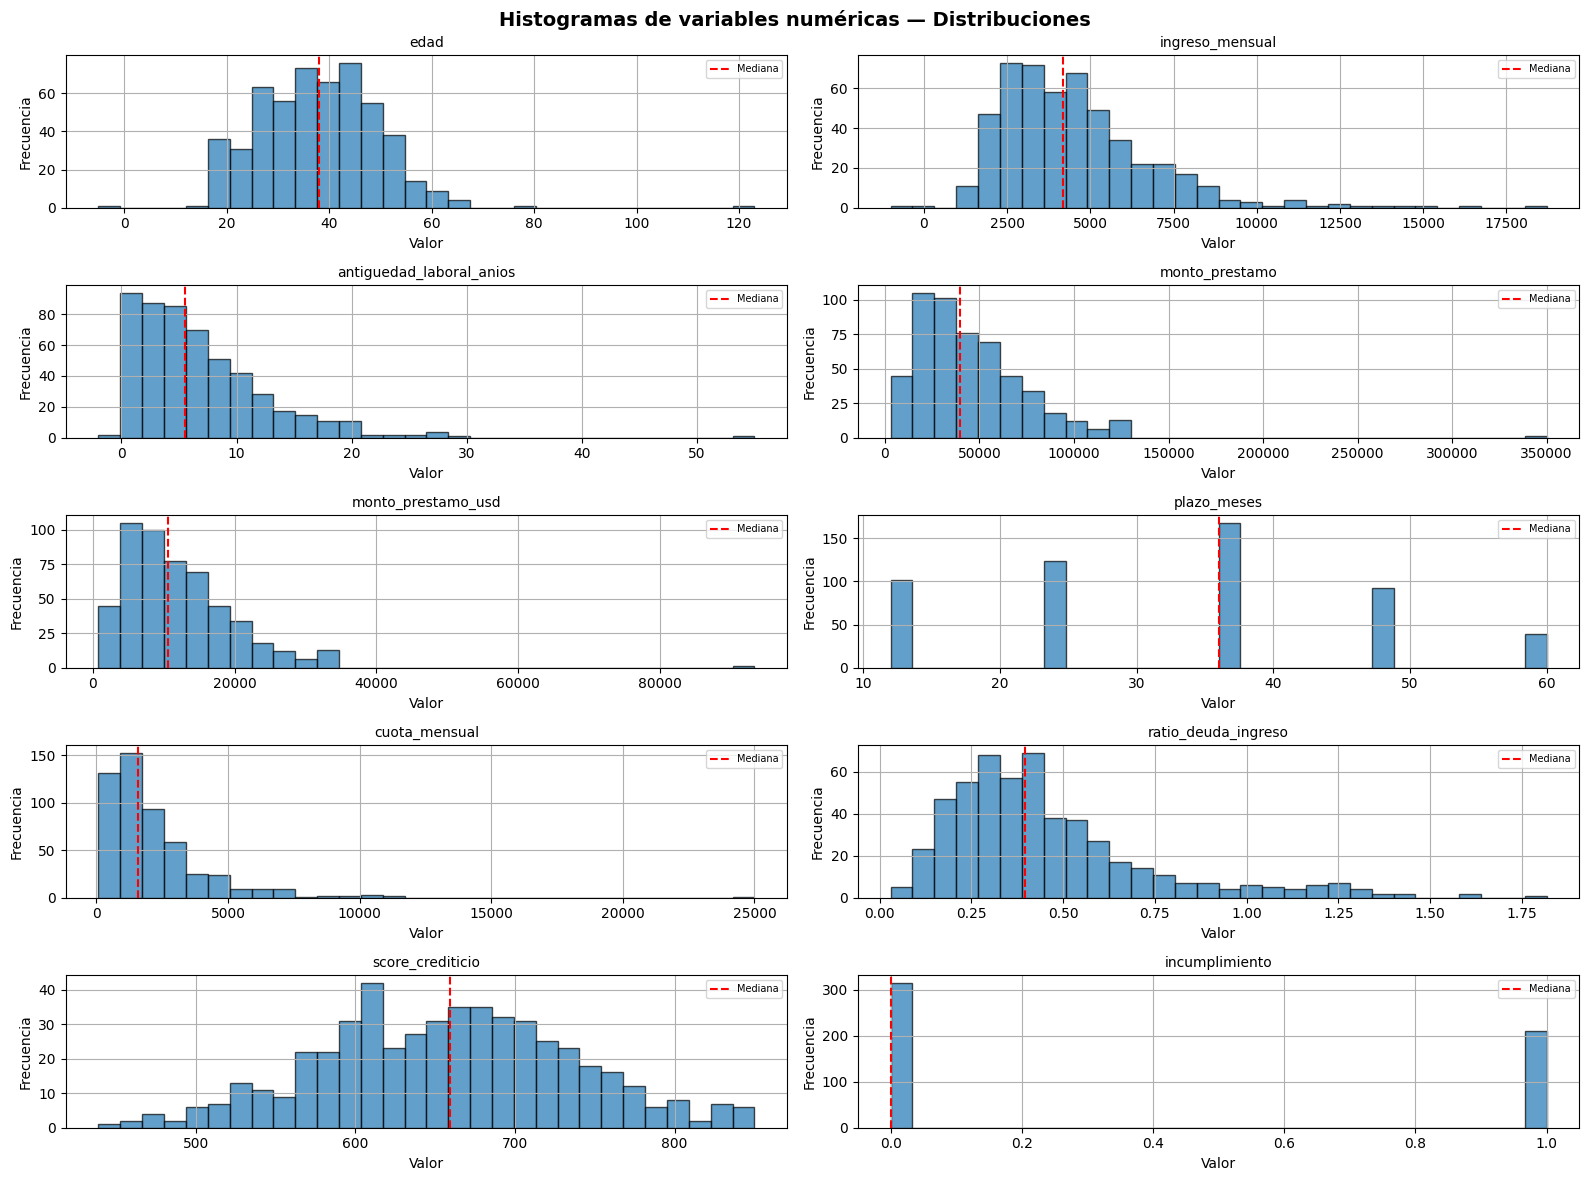

In [59]:
# 2.2 Histogramas para ver la distribución y detectar valores anómalos
# ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(5, 2, figsize=(16, 12))
fig.suptitle('Histogramas de variables numéricas — Distribuciones', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), num_cols):
    df[col].dropna().hist(bins=30, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.axvline(df[col].median(), color='red', linestyle='--', label='Mediana')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

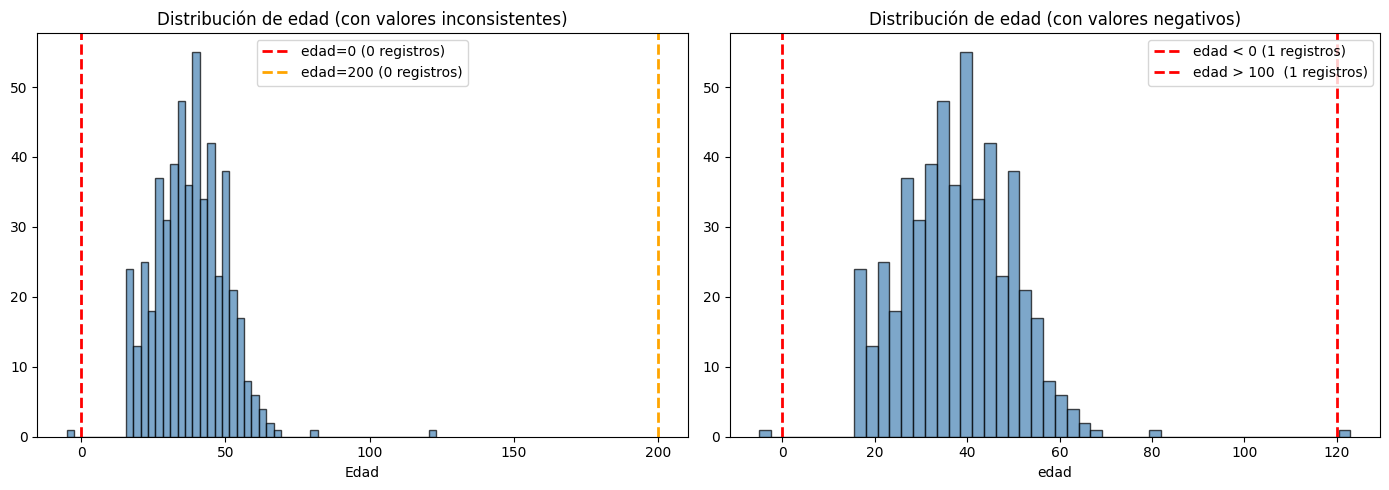

In [60]:
#Gráfico específico: Detalle de los valores problemáticos de edad
# ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: Distribución completa de edad (con los valores problemáticos)
axes[0].hist(df['edad'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linewidth=2, linestyle='--', label=f'edad=0 ({(df["edad"]==0).sum()} registros)')
axes[0].axvline(x=200, color='orange', linewidth=2, linestyle='--', label=f'edad=200 ({(df["edad"]==200).sum()} registros)')
axes[0].set_title('Distribución de edad (con valores inconsistentes)')
axes[0].set_xlabel('Edad')
axes[0].legend()

# Derecha: Distribución de MonthlyIncome destacando negativos
axes[1].hist(df['edad'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='red', linewidth=2, linestyle='--', label=f'edad < 0 ({(df["edad"]<0).sum()} registros)')
axes[1].axvline(x=120, color='red', linewidth=2, linestyle='--', label=f'edad > 100  ({(df["edad"]>100).sum()} registros)')
axes[1].set_title('Distribución de edad (con valores negativos)')
axes[1].set_xlabel('edad')
axes[1].legend()

plt.tight_layout()
plt.show()

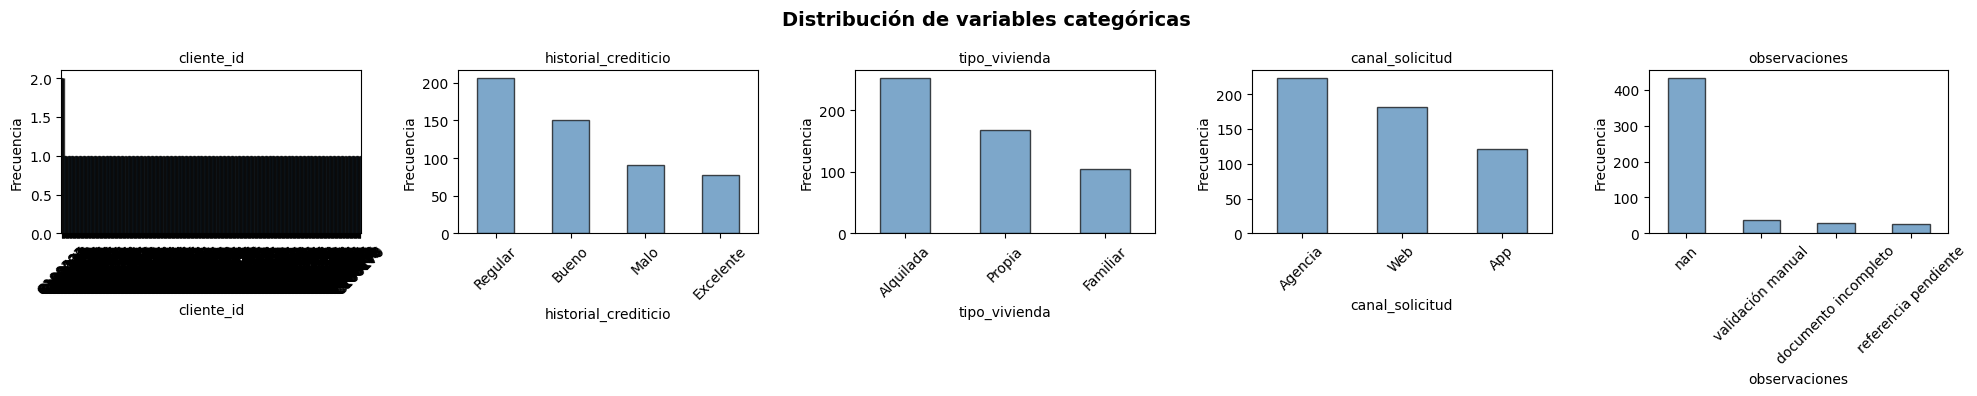

In [61]:
# 2.4 Gráficos de barras para variables categóricas
# ──────────────────────────────────────────────────

cat_cols = ['cliente_id', 'historial_crediticio', 'tipo_vivienda', 'canal_solicitud', 'observaciones']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Distribución de variables categóricas', fontsize=14, fontweight='bold')

for ax, col in zip(axes, cat_cols):
    df[col].value_counts(dropna=False).plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



## Paso 3: Eliminación de columnas irrelevantes o no informativas
Eliminamos columnas que no aportan información útil para un modelo predictivo, con la siguiente justificación:

| Columna | Razón de eliminación |
|---|---|
| **ClienteId** | Es un identificador único (ID). No tiene poder predictivo; simplemente enumera registros. Incluirlo en un modelo causaría overfitting ya que cada valor es único. |
| **observaciones** | Son comentarios administrativosdonde se selaka la validacion manual docuemnto incompelto referencia pendinte no influire en el modelo de prediccion ademas de tener muchos valores nulos Tiene un **82.29% de valores nulos imputar sería inventar datos y cualquier análisis basado en esta columna carecería de validez estadística |


In [62]:
# 3.1 Eliminar columnas irrelevantes o no informativas
# ────────────────────────────────────────────────────

cols_to_drop = ['cliente_id', 'observaciones']

print("Columnas antes de la eliminación:", df.shape[1])
print(f"Columnas a eliminar: {cols_to_drop}")

df_clean = df.drop(columns=cols_to_drop)

print(f"Columnas después de la eliminación: {df_clean.shape[1]}")
print(f"\nColumnas restantes:")
for i, col in enumerate(df_clean.columns, 1):
    print(f"  {i:2d}. {col} ({df_clean[col].dtype})")

Columnas antes de la eliminación: 15
Columnas a eliminar: ['cliente_id', 'observaciones']
Columnas después de la eliminación: 13

Columnas restantes:
   1. edad (float64)
   2. ingreso_mensual (float64)
   3. antiguedad_laboral_anios (float64)
   4. monto_prestamo (float64)
   5. monto_prestamo_usd (float64)
   6. plazo_meses (int64)
   7. cuota_mensual (float64)
   8. ratio_deuda_ingreso (float64)
   9. score_crediticio (float64)
  10. historial_crediticio (object)
  11. tipo_vivienda (object)
  12. canal_solicitud (object)
  13. incumplimiento (int64)


In [63]:
# 3.2 Verificar que no hay valores nulos en las columnas restantes
print("Valores nulos en las columnas restantes:")
print(df_clean.isnull().sum())
print(f"\nTotal de registros: {df_clean.shape[0]}")

Valores nulos en las columnas restantes:
edad                         0
ingreso_mensual             18
antiguedad_laboral_anios     0
monto_prestamo               0
monto_prestamo_usd           0
plazo_meses                  0
cuota_mensual                0
ratio_deuda_ingreso          0
score_crediticio            16
historial_crediticio         0
tipo_vivienda                0
canal_solicitud              0
incumplimiento               0
dtype: int64

Total de registros: 525


In [64]:
df_clean.dropna(subset=['ingreso_mensual'], inplace=True)
df_clean.dropna(subset=['score_crediticio'], inplace=True)

print(df_clean.isnull().sum())

edad                        0
ingreso_mensual             0
antiguedad_laboral_anios    0
monto_prestamo              0
monto_prestamo_usd          0
plazo_meses                 0
cuota_mensual               0
ratio_deuda_ingreso         0
score_crediticio            0
historial_crediticio        0
tipo_vivienda               0
canal_solicitud             0
incumplimiento              0
dtype: int64


## Paso 4: Corrección de valores inconsistentes y outliers

In [65]:
# 4.1 Corregir valores negativos en edad
# ────────────────────────────────────────────────

print(f"Registros con edad < 0: {(df_clean['edad'] < 0).sum()}")
print(f"Rango de valores negativos: [{df_clean['edad'].min()}, {df_clean[df_clean['edad']<0]['edad'].max()}]")
print(f"Rango de |valores negativos|: [{abs(df_clean[df_clean['edad']<0]['edad']).min()}, {abs(df_clean[df_clean['edad']<0]['edad']).max()}]")

# Corrección: valor absoluto
df_clean['edad'] = df_clean['edad'].abs()

print(f"\nDespués de la corrección:")
print(f"  Mínimo: ${df_clean['edad'].min():,}")
print(f"  Máximo: ${df_clean['edad'].max():,}")
print(f"  Negativos restantes: {(df_clean['edad'] < 0).sum()}")

Registros con edad < 0: 1
Rango de valores negativos: [-5.0, -5.0]
Rango de |valores negativos|: [5.0, 5.0]

Después de la corrección:
  Mínimo: $5.0
  Máximo: $123.0
  Negativos restantes: 0


In [66]:
# 4.1 Corregir valores negativos en ingreso_mensual
# ────────────────────────────────────────────────

print(f"Registros con ingreso_mensual < 0: {(df_clean['ingreso_mensual'] < 0).sum()}")
print(f"Rango de valores negativos: [{df_clean['ingreso_mensual'].min()}, {df_clean[df_clean['ingreso_mensual']<0]['ingreso_mensual'].max()}]")
print(f"Rango de |valores negativos|: [{abs(df_clean[df_clean['ingreso_mensual']<0]['ingreso_mensual']).min()}, {abs(df_clean[df_clean['ingreso_mensual']<0]['ingreso_mensual']).max()}]")

# Corrección: valor absoluto
df_clean['ingreso_mensual'] = df_clean['ingreso_mensual'].abs()

print(f"\nDespués de la corrección:")
print(f"  Mínimo: ${df_clean['ingreso_mensual'].min():,}")
print(f"  Máximo: ${df_clean['ingreso_mensual'].max():,}")
print(f"  Negativos restantes: {(df_clean['ingreso_mensual'] < 0).sum()}")

Registros con ingreso_mensual < 0: 1
Rango de valores negativos: [-1000.0, -1000.0]
Rango de |valores negativos|: [1000.0, 1000.0]

Después de la corrección:
  Mínimo: $0.0
  Máximo: $18,710.38
  Negativos restantes: 0


In [67]:
#  Corregir valores negativos en antiguedad_laboral_anios
# ────────────────────────────────────────────────

print(f"Registros con antiguedad_laboral_anios < 0: {(df_clean['antiguedad_laboral_anios'] < 0).sum()}")
print(f"Rango de valores negativos: [{df_clean['antiguedad_laboral_anios'].min()}, {df_clean[df_clean['antiguedad_laboral_anios']<0]['antiguedad_laboral_anios'].max()}]")
print(f"Rango de |valores negativos|: [{abs(df_clean[df_clean['antiguedad_laboral_anios']<0]['antiguedad_laboral_anios']).min()}, {abs(df_clean[df_clean['antiguedad_laboral_anios']<0]['antiguedad_laboral_anios']).max()}]")

# Corrección: valor absoluto
df_clean['antiguedad_laboral_anios'] = df_clean['antiguedad_laboral_anios'].abs()

print(f"\nDespués de la corrección:")
print(f"  Mínimo: ${df_clean['antiguedad_laboral_anios'].min():,}")
print(f"  Máximo: ${df_clean['antiguedad_laboral_anios'].max():,}")
print(f"  Negativos restantes: {(df_clean['antiguedad_laboral_anios'] < 0).sum()}")

Registros con antiguedad_laboral_anios < 0: 2
Rango de valores negativos: [-2.0, -1.0]
Rango de |valores negativos|: [1.0, 2.0]

Después de la corrección:
  Mínimo: $0.0
  Máximo: $55.0
  Negativos restantes: 0


In [68]:
#  Verificacion de negativos faltanates
print(f"Registros con monto_prestamo < 0: {(df_clean['monto_prestamo'] < 0).sum()}")
print(f"Registros con monto_prestamo_usd < 0: {(df_clean['monto_prestamo_usd'] < 0).sum()}")
print(f"Registros con plazo_meses < 0: {(df_clean['plazo_meses'] < 0).sum()}")
print(f"Registros con cuota_mensual < 0: {(df_clean['cuota_mensual'] < 0).sum()}")
print(f"Registros con ratio_deuda_ingreso < 0: {(df_clean['ratio_deuda_ingreso'] < 0).sum()}")
print(f"Registros con ratio_deuda_ingreso > 1: {(df_clean['ratio_deuda_ingreso'] > 1).sum()}")
print(f"Registros con score_crediticio < 0: {(df_clean['score_crediticio'] < 0).sum()}")



Registros con monto_prestamo < 0: 0
Registros con monto_prestamo_usd < 0: 0
Registros con plazo_meses < 0: 0
Registros con cuota_mensual < 0: 0
Registros con ratio_deuda_ingreso < 0: 0
Registros con ratio_deuda_ingreso > 1: 34
Registros con score_crediticio < 0: 0


In [69]:
# Eliminar registros donde 'edad' es mayor a 100
print(f"Registros con edad = 0: {(df_clean['edad'] == 0).sum()}")
print(f"Registros con edad = 125: {(df_clean['edad'] == 125).sum()}")

df_clean = df_clean[~df_clean['edad'].isin([0, 200])]


Registros con edad = 0: 0
Registros con edad = 125: 0


In [70]:
# 4.2 Detección de outliers con el método IQR
# ──────────────────────────────────────────────

# Listas de variable  numericas a winsorización
numeric_cols = ['edad', 'ingreso_mensual', 'antiguedad_laboral_anios', 'monto_prestamo',
            'monto_prestamo_usd', 'plazo_meses', 'cuota_mensual',
            'ratio_deuda_ingreso', 'score_crediticio','incumplimiento']
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print("\\nDescripción numérica tras winsorización (IQR):")
df.describe()

\nDescripción numérica tras winsorización (IQR):


,edad,ingreso_mensual,antiguedad_laboral_anios,monto_prestamo,monto_prestamo_usd,plazo_meses,cuota_mensual,ratio_deuda_ingreso,score_crediticio,incumplimiento
count,525.000000,507.000000,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,509.000000,525.000000
mean,37.805714,4555.178245,6.777333,45299.877390,12080.408502,32.388571,2187.250305,0.459276,657.086444,0.400000
std,11.825560,2368.835238,5.961691,30128.899743,8034.388907,14.187454,2099.579078,0.287385,79.357610,0.490365
min,-5.000000,-1000.000000,-2.000000,3000.000000,789.520000,12.000000,79.610000,0.030000,439.000000,0.000000
25%,29.000000,2894.630000,2.500000,22598.770000,6017.030000,24.000000,901.210000,0.269000,603.000000,0.000000
50%,38.000000,4171.800000,5.500000,39702.910000,10578.470000,36.000000,1595.560000,0.395000,659.000000,0.000000
75%,46.000000,5562.140000,9.500000,60564.380000,16133.720000,36.000000,2717.150000,0.554000,710.000000,1.000000
max,123.000000,18710.380000,55.000000,350000.000000,93333.333333,60.000000,25000.000000,1.817000,850.000000,1.000000


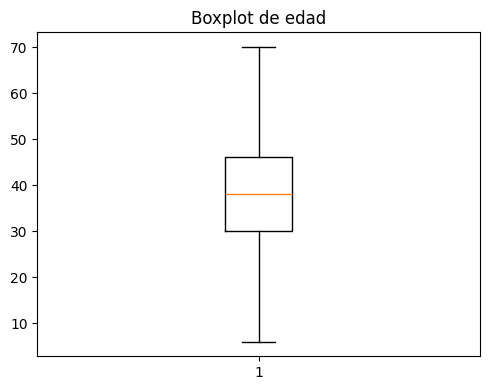

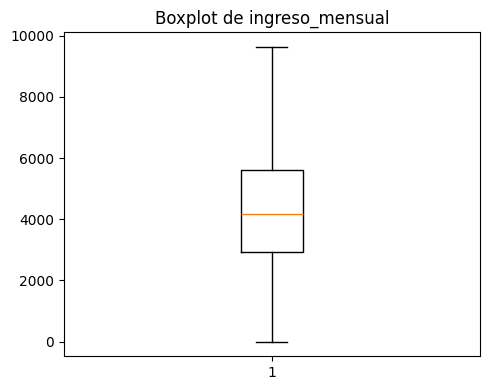

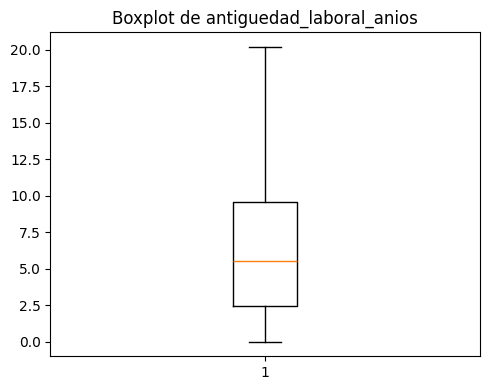

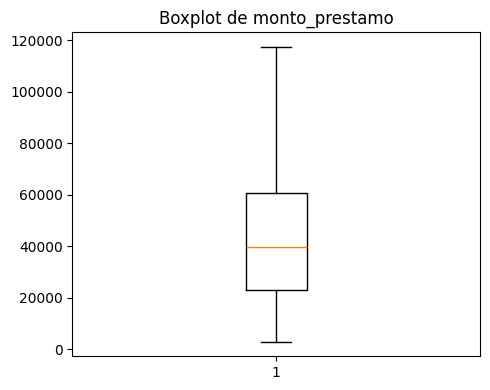

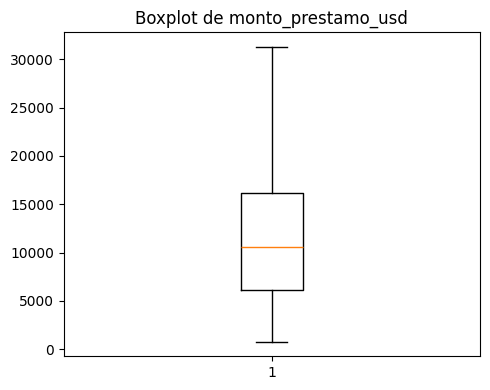

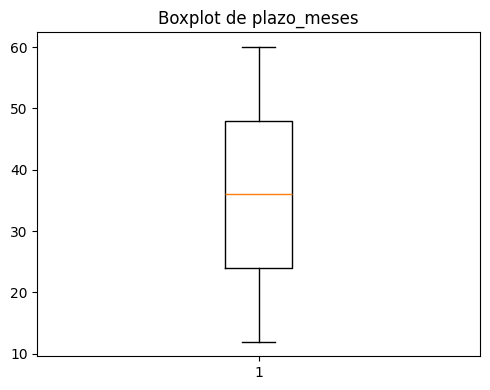

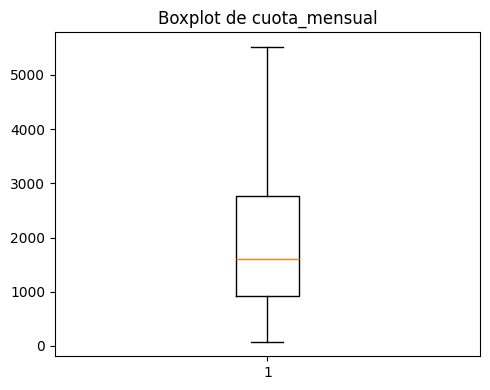

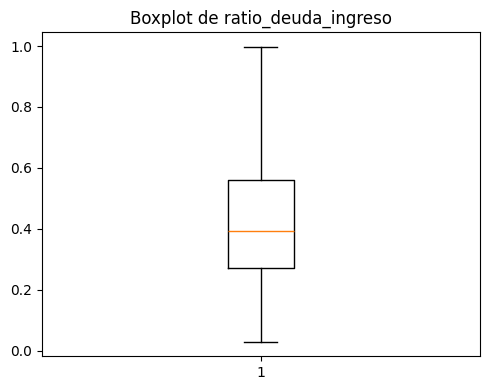

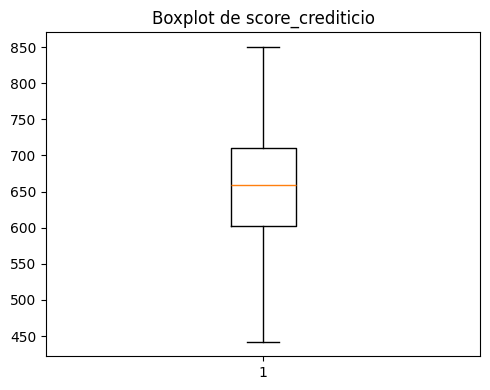

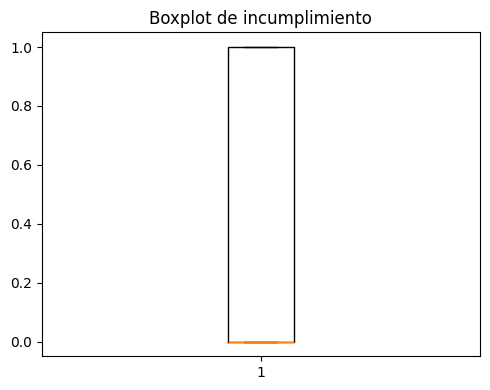

In [71]:
# Boxplots para ver si se removieron outliers numéricos
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    plt.figure(figsize=(5, 4))
    plt.boxplot(df_clean[col].dropna().values, vert=True, showfliers=True)
    plt.title(f'Boxplot de {col}')
    plt.tight_layout()
    plt.show()

In [72]:
# 1.1 Información general del nuevo dataset
print("="*60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*60)
print(f"\nDimensiones: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas")
print(f"\nColumnas del dataset:")
for i, col in enumerate(df_clean.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nTipos de datos:")
print(df_clean.dtypes)

INFORMACIÓN GENERAL DEL DATASET

Dimensiones: 491 filas x 13 columnas

Columnas del dataset:
   1. edad
   2. ingreso_mensual
   3. antiguedad_laboral_anios
   4. monto_prestamo
   5. monto_prestamo_usd
   6. plazo_meses
   7. cuota_mensual
   8. ratio_deuda_ingreso
   9. score_crediticio
  10. historial_crediticio
  11. tipo_vivienda
  12. canal_solicitud
  13. incumplimiento

Tipos de datos:
edad                        float64
ingreso_mensual             float64
antiguedad_laboral_anios    float64
monto_prestamo              float64
monto_prestamo_usd          float64
plazo_meses                   int64
cuota_mensual               float64
ratio_deuda_ingreso         float64
score_crediticio            float64
historial_crediticio         object
tipo_vivienda                object
canal_solicitud              object
incumplimiento                int64
dtype: object


**2) Codifique/recodifique las variables categóricas con la codificación adecuada: Label Encoding para variables ordinales y One-Hot Encoding para variables nominales. Justifique sus elecciones.** (1 punto)


In [73]:
# Identificar variables categóricas
print("Tipos de datos:")
print(df.dtypes)
print("\nValores únicos de historial_crediticio:", df['historial_crediticio'].unique())
print("Valores únicos de tipo_vivienda:", df['tipo_vivienda'].unique())
print("Valores únicos de canal_solicitud:", df['canal_solicitud'].unique())


Tipos de datos:
cliente_id                   object
edad                        float64
ingreso_mensual             float64
antiguedad_laboral_anios    float64
monto_prestamo              float64
monto_prestamo_usd          float64
plazo_meses                   int64
cuota_mensual               float64
ratio_deuda_ingreso         float64
score_crediticio            float64
historial_crediticio         object
tipo_vivienda                object
canal_solicitud              object
observaciones                object
incumplimiento                int64
dtype: object

Valores únicos de historial_crediticio: ['Regular' 'Malo' 'Excelente' 'Bueno']
Valores únicos de tipo_vivienda: ['Alquilada' 'Familiar' 'Propia']
Valores únicos de canal_solicitud: ['App' 'Agencia' 'Web']


In [74]:
# 'historial_crediticio' se deja como numérica (es ordinal con significado cuantitativo: más historial = más consumo)
# 'tipo_vivienda' es categórica nominal (string) -> One-Hot Encoding
# 'canal_solicitud' es categórica nominal (string) -> One-Hot Encoding

In [75]:
# historial_crediticio: Codificación ordinal
# ─────────────────────────────────────────────
# Justificación: Esta variable tiene un ORDEN NATURAL (Excelente > Regular > Regular > Malo).
# Según el enunciado: A=Excelente, B=Bien, C=Mediocre, D=Bajo rendimiento.
# Asignamos valores numéricos que reflejan esta jerarquía:
# Usar one-hot encoding aquí sería INCORRECTO porque se perdería la relación
# de orden entre las categorías.

print("Antes:", df_clean['historial_crediticio'].value_counts().to_dict())

ordinal_map = {'Excelente': 4, 'Bueno': 3, 'Regular': 2, 'Malo': 1}
df_clean['historial_crediticio'] = df_clean['historial_crediticio'].map(ordinal_map)

print("Después:", df_clean['historial_crediticio'].value_counts().to_dict())
print(f"Tipo de dato: {df_clean['historial_crediticio'].dtype}")

Antes: {'Regular': 191, 'Bueno': 142, 'Malo': 86, 'Excelente': 72}
Después: {2: 191, 3: 142, 1: 86, 4: 72}
Tipo de dato: int64


In [76]:
# tipo_vivienda: One-Hot Encoding
# ─────────────────────────────────────
# Justificación: El estado tipo de vivienda (sin orden natural).
# No podemos decir que "Alquilada > Familiar > Propia".
# One-hot encoding crea una columna binaria por cada categoría, lo cual
# permite al modelo tratar cada estado de forma independiente.
#
# Usamos drop_first=True para evitar la trampa de la multicolinealidad
# (dummy variable trap): si sabemos que Alquilada=0 y
# Familiar=0, entonces necesariamente es "Propia".

print("Antes:", df_clean['tipo_vivienda'].value_counts().to_dict())

df_clean = pd.get_dummies(df_clean, columns=['tipo_vivienda'], drop_first=True, dtype=int)

print("\nColumnas creadas:", [c for c in df_clean.columns if 'tipo' in c])
print(df_clean[[c for c in df_clean.columns if 'tipo' in c]].head())

# canal_solicitud: One-Hot Encoding
# ─────────────────────────────────────
# Justificación: El estado tipo de vivienda (sin orden natural).
# No podemos decir que "App > Agencia > Web".
# One-hot encoding crea una columna binaria por cada categoría, lo cual
# permite al modelo tratar cada estado de forma independiente.
#
# Usamos drop_first=True para evitar la trampa de la multicolinealidad
# (dummy variable trap): si sabemos que App=0 y
# Agencia=0, entonces necesariamente es "Web".

print("Antes:", df_clean['canal_solicitud'].value_counts().to_dict())

df_clean = pd.get_dummies(df_clean, columns=['canal_solicitud'], drop_first=True, dtype=int)

print("\nColumnas creadas:", [c for c in df_clean.columns if 'canal' in c])
print(df_clean[[c for c in df_clean.columns if 'canal' in c]].head())

Antes: {'Alquilada': 234, 'Propia': 157, 'Familiar': 100}

Columnas creadas: ['tipo_vivienda_Familiar', 'tipo_vivienda_Propia']
   tipo_vivienda_Familiar  tipo_vivienda_Propia
0                       0                     0
1                       1                     0
3                       0                     1
4                       0                     0
5                       0                     1
Antes: {'Agencia': 209, 'Web': 173, 'App': 109}

Columnas creadas: ['canal_solicitud_App', 'canal_solicitud_Web']
   canal_solicitud_App  canal_solicitud_Web
0                    1                    0
1                    0                    0
3                    1                    0
4                    0                    1
5                    0                    1


**3) Genere e interprete un plot de correlaciones entre las variables numéricas. Si observa pares de variables con correlaciones elevadas mayores a 0.95, escoja solo una de ellas y justifique la decisión.** (1 punto)


In [77]:
numericals = ['edad', 'ingreso_mensual', 'antiguedad_laboral_anios', 'monto_prestamo',
            'monto_prestamo_usd', 'plazo_meses', 'cuota_mensual',
            'ratio_deuda_ingreso', 'score_crediticio','incumplimiento']


In [78]:
corr = df_clean[numericals].corr()
print("\\nMatriz de correlaciones (numéricas):")
corr.round(2)

\nMatriz de correlaciones (numéricas):


,edad,ingreso_mensual,antiguedad_laboral_anios,monto_prestamo,monto_prestamo_usd,plazo_meses,cuota_mensual,ratio_deuda_ingreso,score_crediticio,incumplimiento
edad,1.00,0.03,0.66,0.06,0.06,-0.05,0.06,0.08,0.05,-0.01
ingreso_mensual,0.03,1.00,-0.01,0.78,0.78,-0.06,0.64,0.09,0.09,0.02
antiguedad_laboral_anios,0.66,-0.01,1.00,0.01,0.01,-0.03,0.03,0.09,0.05,-0.02
monto_prestamo,0.06,0.78,0.01,1.00,1.00,0.00,0.75,0.39,0.11,0.14
monto_prestamo_usd,0.06,0.78,0.01,1.00,1.00,0.00,0.75,0.39,0.11,0.14
plazo_meses,-0.05,-0.06,-0.03,0.00,0.00,1.00,-0.54,-0.66,0.03,-0.22
cuota_mensual,0.06,0.64,0.03,0.75,0.75,-0.54,1.00,0.78,-0.01,0.30
ratio_deuda_ingreso,0.08,0.09,0.09,0.39,0.39,-0.66,0.78,1.00,-0.09,0.40
score_crediticio,0.05,0.09,0.05,0.11,0.11,0.03,-0.01,-0.09,1.00,-0.41
incumplimiento,-0.01,0.02,-0.02,0.14,0.14,-0.22,0.30,0.40,-0.41,1.00


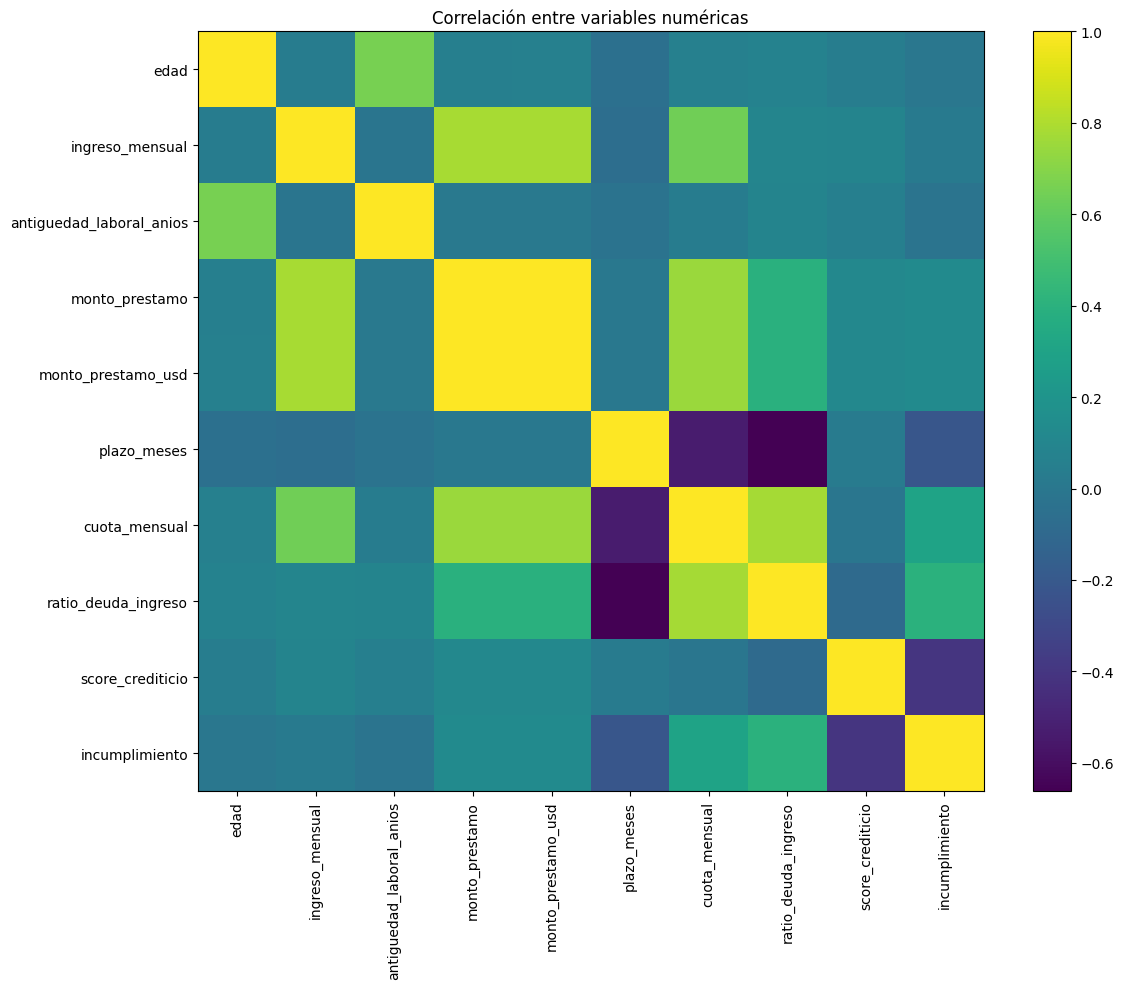

In [79]:
# Plot de matriz de correlaciones
plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap='viridis', aspect='auto')
plt.title('Correlación entre variables numéricas')
plt.colorbar()
plt.xticks(range(len(numericals)), numericals, rotation=90)
plt.yticks(range(len(numericals)), numericals)
plt.tight_layout()
plt.show()

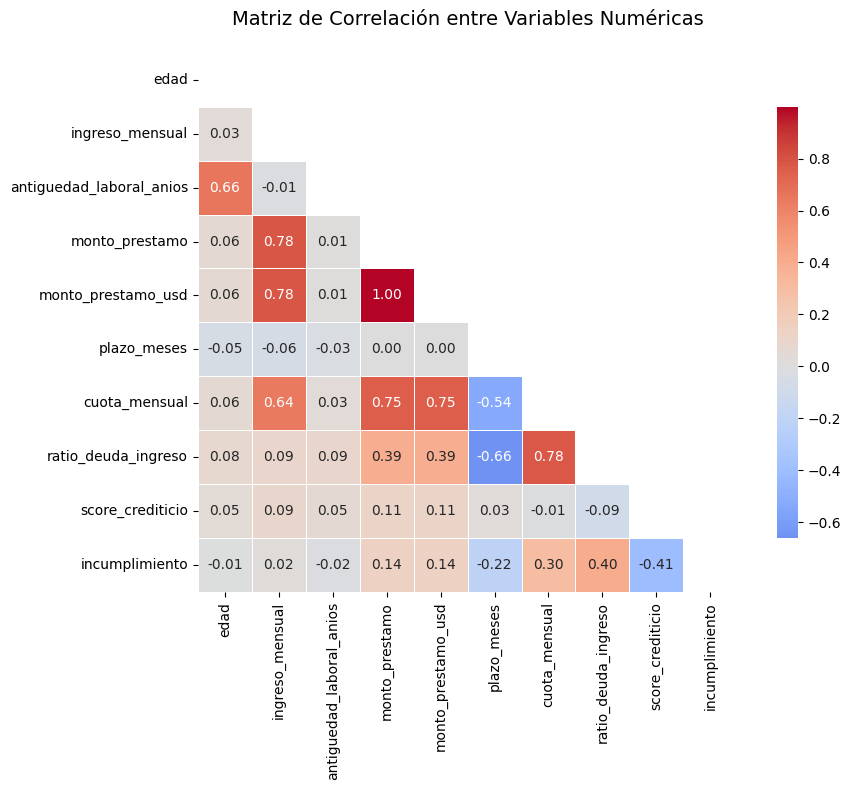

In [80]:
correlation_matrix = df_clean[numericals].corr()

# Visualizar
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación entre Variables Numéricas', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

Se puede ver lo que es el monto de prestamos usd con el monto de prestamo es natural que se hayan una correlacion dado que la accion en si es prestarsea pero vale tambien destacar el monto de presato con el ingreso mensual sigue igual de correlaciones  al igual que el ratio deuda ingreso con la cuota mensual

In [81]:
#Funcion para dropear columnas altamente correlacionadas (con correlacion mayor a threshold)
def drop_highly_correlated(dataframe, threshold=0.95, verbose=True):
    """Elimina variables numéricas redundantes por alta correlación (|ρ|>threshold).
    Estrategia codiciosa: remueve en cada paso la variable con mayor 'redundancia';
    en caso de empate, la de menor varianza."""
    df_num = dataframe.select_dtypes(include=[np.number]).copy()
    dropped = []
    iteration = 0

    while True:
        corr = df_num.corr().abs()
        # Considerar solo triángulo superior para encontrar pares
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        # Pares por encima del umbral
        pairs = [(i, j, upper.loc[i, j]) for i in upper.index for j in upper.columns if pd.notna(upper.loc[i, j]) and upper.loc[i, j] > threshold]
        if not pairs:
            break

        # Calcular 'redundancia' = cantidad de correlaciones > threshold por variable
        redundancy = (upper > threshold).sum(axis=0) + (upper > threshold).sum(axis=1)
        redundancy = redundancy.groupby(level=0).sum()  # asegura índice correcto
        # Candidatas con mayor redundancia
        max_red = redundancy.max()
        candidates = redundancy[redundancy == max_red].index.tolist()

        # Empate → escoger la de menor varianza (más "poco informativa")
        if len(candidates) > 1:
            variances = df_num[candidates].var(numeric_only=True)
            to_drop = variances.idxmin()
        else:
            to_drop = candidates[0]

        if verbose:
            print(f"[Iter {iteration}] Umbral={threshold} → Drop: {to_drop} (redundancia={max_red}, var={df_num[to_drop].var():.4f})")

        dropped.append(to_drop)
        df_num = df_num.drop(columns=[to_drop])
        iteration += 1

    # Aplicar drop al dataframe original
    dataframe.drop(columns=[c for c in dropped if c in dataframe.columns], inplace=True)
    return dropped

In [82]:
# dropea
dropped_corr_cols = drop_highly_correlated(df_clean, threshold=0.95, verbose=True)

[Iter 0] Umbral=0.95 → Drop: monto_prestamo_usd (redundancia=1, var=53131626.1021)


In [83]:
print("\nResumen eliminación de redundancias por alta correlación:")
if dropped_corr_cols:
    print("Columnas eliminadas por alta correlación:", dropped_corr_cols)
else:
    print("No se eliminaron columnas por alta correlación con el umbral dado.")


Resumen eliminación de redundancias por alta correlación:
Columnas eliminadas por alta correlación: ['monto_prestamo_usd']


In [84]:
# Guardar dataset procesado
df_clean.to_csv("data_parcial_procesado.csv", index=False)

In [85]:
dataset = 'data_parcial_procesado.csv'

df_nuevo = pd.read_csv(dataset)
print("Se leyó un dataset de dimensiones {}".format(df_nuevo.shape))
df_nuevo.head(10)

Se leyó un dataset de dimensiones (491, 14)


,edad,ingreso_mensual,antiguedad_laboral_anios,monto_prestamo,plazo_meses,cuota_mensual,ratio_deuda_ingreso,score_crediticio,historial_crediticio,incumplimiento,tipo_vivienda_Familiar,tipo_vivienda_Propia,canal_solicitud_App,canal_solicitud_Web
0,29.0,4808.61,4.4,28681.11,48,953.49,0.19800,591.0,2,1,0,0,1,0
1,18.0,1903.01,0.0,12550.13,24,710.19,0.37300,503.0,1,1,1,0,0,0
2,16.0,4923.31,11.2,33253.74,36,1026.78,0.20900,754.0,4,0,0,1,1,0
3,35.0,3380.26,2.9,26736.21,24,1376.73,0.40700,601.0,2,1,0,0,0,1
4,42.0,4351.09,16.3,10786.05,48,342.30,0.07900,586.0,2,0,0,1,0,1
5,57.0,8003.21,11.6,61389.00,36,1969.64,0.24600,718.0,3,0,1,0,0,1
6,50.0,3025.27,4.3,41367.38,12,3744.20,0.99675,669.0,2,1,0,0,0,0
7,46.0,1974.71,10.5,19486.28,48,476.47,0.24100,675.0,3,0,0,1,0,0
8,46.0,3571.64,7.7,31448.65,36,1133.41,0.31700,644.0,2,0,1,0,0,0
9,29.0,2845.58,0.8,15417.61,24,840.19,0.29500,545.0,1,1,0,1,1,0


In [86]:
# Información general del nuevo dataset
print("="*60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*60)
print(f"\nDimensiones: {df_nuevo.shape[0]} filas x {df_nuevo.shape[1]} columnas")
print(f"\nColumnas del dataset:")
for i, col in enumerate(df_nuevo.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nTipos de datos:")
print(df_nuevo.dtypes)

INFORMACIÓN GENERAL DEL DATASET

Dimensiones: 491 filas x 14 columnas

Columnas del dataset:
   1. edad
   2. ingreso_mensual
   3. antiguedad_laboral_anios
   4. monto_prestamo
   5. plazo_meses
   6. cuota_mensual
   7. ratio_deuda_ingreso
   8. score_crediticio
   9. historial_crediticio
  10. incumplimiento
  11. tipo_vivienda_Familiar
  12. tipo_vivienda_Propia
  13. canal_solicitud_App
  14. canal_solicitud_Web

Tipos de datos:
edad                        float64
ingreso_mensual             float64
antiguedad_laboral_anios    float64
monto_prestamo              float64
plazo_meses                   int64
cuota_mensual               float64
ratio_deuda_ingreso         float64
score_crediticio            float64
historial_crediticio          int64
incumplimiento                int64
tipo_vivienda_Familiar        int64
tipo_vivienda_Propia          int64
canal_solicitud_App           int64
canal_solicitud_Web           int64
dtype: object


In [87]:
#Valores nulos por columna
print("="*60)
print("VALORES NULOS POR COLUMNA")
print("="*60)
null_info = pd.DataFrame({
    'Nulos': df_nuevo.isnull().sum(),
    '% Nulos': (df_nuevo.isnull().mean() * 100).round(2)
})
print(null_info[null_info['Nulos'] > 0])
print(f"\nTotal de filas con al menos un nulo: {df_nuevo.isnull().any(axis=1).sum()}")

VALORES NULOS POR COLUMNA
Empty DataFrame
Columns: [Nulos, % Nulos]
Index: []

Total de filas con al menos un nulo: 0


**4) Dividir el dataset procesado en dos conjuntos: train y test. Usar 80% de los datos para train y 20% para test.** (0 puntos)


In [88]:
# Cargar libreriras y modulos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest   # para seleccionar atributos de forma univariada (filtros)
from sklearn.feature_selection import chi2   # estadististica para evaluar la importancia de atributos en relacion al target
from sklearn.feature_selection import RFE    # metodo recursive featute elimination
from sklearn.decomposition import PCA        # para transformacion PCA

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis  # para modelos discriminantes lineales
from sklearn.naive_bayes import GaussianNB   # para modelos Naive Bayes
from sklearn.linear_model import LogisticRegression # para usar modelos de regresion logistica
from sklearn.tree import DecisionTreeClassifier     # para usar modelos de tipo arboles de decision
from sklearn.neighbors import KNeighborsClassifier  # para modelos  Knn
from sklearn.svm import SVC   # para modelos SVM
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split  # para partir los datos en conjuntos de entrenamiento y validacion
from sklearn.model_selection import KFold  # para partir la data en k-folds
from sklearn.model_selection import cross_val_score   # para evaluar algoritmos en cross validacion

from sklearn.metrics import accuracy_score, balanced_accuracy_score   # para manejar metricas de desempeño
from sklearn.metrics import classification_report  # para hacer reportes de resultados de clasificacion
from sklearn.metrics import confusion_matrix  # para manejar matrices de confusion
from sklearn.metrics import jaccard_score  # indice jacard



In [89]:
# carga el dataset pima-indians-diabetes
filename = 'data_parcial_procesado.csv'
dataset = pd.read_csv(filename)

# separa el dataset en atributos (X) y target (y) usando nombres de columnas
X = dataset.drop('incumplimiento', axis=1)  # todos los atributos excepto 'class'
y = dataset['incumplimiento']                # solo la columna 'class'

# realiza el train-test split
valid_fraction = 0.20    # proporcion de muestras para validacion
seed = 7   # semilla para el generador aleatorio (para reproductibilidad)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=valid_fraction, random_state=seed)

print('Training: %d ejemplos. Validation: %d ejemplos' % (len(y_train), len(y_test)))

Training: 392 ejemplos. Validation: 99 ejemplos


In [90]:
dataset.describe()

,edad,ingreso_mensual,antiguedad_laboral_anios,monto_prestamo,plazo_meses,cuota_mensual,ratio_deuda_ingreso,score_crediticio,historial_crediticio,incumplimiento,tipo_vivienda_Familiar,tipo_vivienda_Propia,canal_solicitud_App,canal_solicitud_Web
count,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000
mean,37.816701,4488.307454,6.620163,45275.662749,32.358452,2035.221823,0.442053,657.058045,2.407332,0.399185,0.203666,0.319756,0.221996,0.352342
std,11.257424,2039.257628,5.292041,27338.950867,14.196357,1450.312584,0.238922,79.197552,0.941702,0.490230,0.403134,0.466857,0.416012,0.478187
min,6.000000,0.000000,0.000000,3000.000000,12.000000,79.610000,0.030000,442.500000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,2914.460000,2.450000,22838.500000,24.000000,929.265000,0.270500,603.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,38.000000,4181.820000,5.500000,39821.130000,36.000000,1607.820000,0.393000,659.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,46.000000,5600.340000,9.550000,60629.700000,48.000000,2763.690000,0.561000,710.000000,3.000000,1.000000,0.000000,1.000000,0.000000,1.000000
max,70.000000,9629.160000,20.200000,117316.500000,60.000000,5515.327500,0.996750,850.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**5) Con el conjunto de train evalúe en cross-validation los siguientes algoritmos de clasificación: Logistic Regression (LR), KNN con K=5, KNN con K=10, Classification and Regression Trees (CART) con `max_depth=10` y CART con `max_depth=None`. Use 10 folds para la cross-validation y como métrica de scoring use `balanced_accuracy`. Muestre boxplots de los resultados de la cross-validation de todos los algoritmos evaluados y comente los resultados.** (2 puntos)


In [91]:
# Definimos el pool de algoritmos de ML a evaluar
algos = []
algos.append(('LogReg', LogisticRegression( solver='liblinear')))  #genera logistic regresors con solver liblinear
algos.append(('5NN', KNeighborsClassifier( n_neighbors=5))) #genera knn con 5 vecinos
algos.append(('10NN', KNeighborsClassifier( n_neighbors=10, ))) #genera knn con 10 vecinos
algos.append(('CART_ten', DecisionTreeClassifier(max_depth=10 ))) # genera DT con 10
algos.append(('CART_none', DecisionTreeClassifier(max_depth=None ))) # genera DT sin restriccion de profundidad

In [92]:
# muestra la distribucion de las clases
print(dataset.groupby('incumplimiento').size())

incumplimiento
0    295
1    196
dtype: int64


In [93]:
# Evaluamos cada algoritmo de ML en estrategia de 10-fold-CV
results = []
names = []

# genera el particionamiento de 10 folds que seran usados en cada evaluacion
seed = 7
kfold = KFold(n_splits=10, random_state=seed, shuffle= True)  # especifica el particionador de datos a 10-folds CV

#  evalua cada algoritmo de ML
for algoname, algo in algos:
    cv_results = cross_val_score(algo, X_train, y_train, cv=kfold, scoring='balanced_accuracy')
    results.append(cv_results)
    names.append(algoname)
    print("{}: {} ({})".format(algoname, cv_results.mean(), cv_results.std()))

LogReg: 0.6838402642678958 (0.10944339431644826)
5NN: 0.5168594677739413 (0.07000034149482492)
10NN: 0.5215880557064768 (0.05561486868742135)
CART_ten: 0.633220335707178 (0.08538252610646296)
CART_none: 0.6307134675753095 (0.06927413155846676)


**6) Con base en los resultados del paso 5, escoja el algoritmo que mejores modelos induce y entrene con él un modelo final usando todos los datos de entrenamiento. Evalúelo en la data separada para prueba en el paso 4. Muestre las métricas Accuracy, Balanced_accuracy en el conjunto de test. Además, muestre la matriz de confusión, classification_report y comente los resultados, indicando qué significan los falsos positivos y falsos negativos en el contexto del problema.** (1 punto)


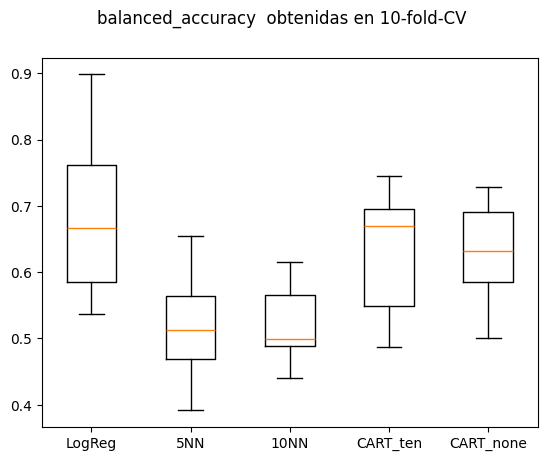

In [94]:
# Muestra graficamente los resultados de balanced_accuracy  en crossvalidacion de los Algoritmos evaluados
fig = plt.figure()
fig.suptitle('balanced_accuracy  obtenidas en 10-fold-CV')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [95]:
# Reentrena modelo LR con todos los datos de entrenamiento y lo prueba en el conjunto de validación
model = LogisticRegression(solver='liblinear', class_weight = 'balanced') #  usar class_weight = 'balanced') para entrenar tomando en cuenta el desbalance
model.fit(X_train, y_train)

# predice la c lase del conjunto de validacion
y_predicted = model.predict(X_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

# muestra la matriz de confusion
# en la matriz de confusion, un elemento Cij es el numero de ejemplos predichos como clase j que son realmente de clase i
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_predicted))

# muestra un reporte de la clasificacion en validacion
print("\nReporte de clasificacion en conjunto de validacion: \n")
print(classification_report(y_test, y_predicted))

Balanced Accuracy score: 0.7648148148148148

Matriz de Confusión:
[[43 11]
 [12 33]]

Reporte de clasificacion en conjunto de validacion: 

              precision    recall  f1-score   support

           0       0.78      0.80      0.79        54
           1       0.75      0.73      0.74        45

    accuracy                           0.77        99
   macro avg       0.77      0.76      0.77        99
weighted avg       0.77      0.77      0.77        99



**7) Trate de mejorar los resultados obtenidos. Se deja a su criterio la elección de cómo mejorar, pero debe justificar su elección (<font color='blue'>ejemplos: pipelines con escalamiento y/o reducción dimensional,  uso de `class_weight`, balanceo de los datos, tuneo de hiperparámetros de los algoritmos, mejora del preprocesamiento de los datos, o combinaciones de los anteriores</font>). Al final se deben mostrar los resultados del modelo optimizado como se hizo en el paso 6, usando el mismo conjunto de test: métricas Accuracy, Balanced_accuracy, matriz de confusión y classification_report. Compare los resultados con los obtenidos en Preg 6. <font color=red>Recibira nota completa en esta pregunta si la mejora en balanced_accuracy es > 1% </font>** (2 puntos)


In [96]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.pipeline import make_pipeline

# Definimos el pool de pipleines de ML (MinMaxScaler + algoritmo de ML) a evaluar
pipelines = []
pipelines.append(('pipLogReg', make_pipeline(MinMaxScaler(),LogisticRegression(solver='liblinear'))))
pipelines.append(('pip5NN', make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=5))))
pipelines.append(('pip10NN', make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=10))))
pipelines.append(('pipCART_none', make_pipeline(MinMaxScaler(), DecisionTreeClassifier(max_depth=None))))
pipelines.append(('pipCART_10', make_pipeline(MinMaxScaler(), DecisionTreeClassifier(max_depth=10))))
pipelines.append(('pipSVM', make_pipeline(MinMaxScaler(), SVC())))

In [51]:
# Evaluamos cada pipeline de ML en estrategia de 10-fold-CV
results = []
names = []

# genera el particionamiento de 10 folds que seran usados en cada evaluacion
seed = 7
kfold = KFold(n_splits=10, random_state=seed, shuffle= True)  # especifica el particionador de datos a 10-folds CV

#  evalua cada pipeline en crosvalidacion
for pipelinename, pipeline in pipelines:
    cv_results = cross_val_score(pipeline, X_train, y_train, cv=kfold, scoring='balanced_accuracy')
    results.append(cv_results)
    names.append(pipelinename)
    print("{}: {} ({})".format(pipelinename, cv_results.mean(), cv_results.std()))

pipLogReg: 0.7312895230987336 (0.06549264397738316)
pip5NN: 0.619859342411974 (0.06997329114360067)
pip10NN: 0.6031523362115467 (0.08025897713028055)
pipCART_none: 0.6525012864815497 (0.08006412865651356)
pipCART_10: 0.6305506235966762 (0.0727232928370915)
pipSVM: 0.6746097932282142 (0.08463856954952113)


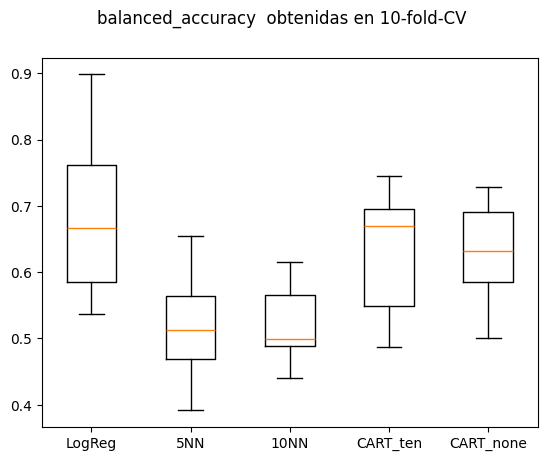

In [97]:
# Muestra graficamente los resultados de balanced_accuracy  en crossvalidacion de los pipelines evaluados
fig = plt.figure()
fig.suptitle('balanced_accuracy  obtenidas en 10-fold-CV')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [98]:
# Reentrena el pipeline ganador con todos los datos de entrenamiento y lo prueba en el conjunto de validación
#model = make_pipeline(StandardScaler(), PCA(n_components=6), LogisticRegression(solver='liblinear',  class_weight = 'balanced')) #  usar class_weight = 'balanced') para entrenar tomando en cuenta el desbalance
#model = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=5))
model = make_pipeline(MinMaxScaler(),LogisticRegression(solver='liblinear',  class_weight = 'balanced'))
model.fit(X_train, y_train)

# predice la c lase del conjunto de validacion
y_predicted = model.predict(X_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

# muestra la matriz de confusion
# en la matriz de confusion, un elemento Cij es el numero de ejemplos predichos como clase j que son realmente de clase i
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_predicted))

# muestra un reporte de la clasificacion en validacion
print("\nReporte de clasificacion en conjunto de validacion:\n")
print(classification_report(y_test, y_predicted))

Balanced Accuracy score: 0.762962962962963

Matriz de Confusión:
[[44 10]
 [13 32]]

Reporte de clasificacion en conjunto de validacion:

              precision    recall  f1-score   support

           0       0.77      0.81      0.79        54
           1       0.76      0.71      0.74        45

    accuracy                           0.77        99
   macro avg       0.77      0.76      0.76        99
weighted avg       0.77      0.77      0.77        99

